# Model Project

Import and set magics:

In [149]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
from Consumer import ConsumerClass
from Government import GovernmentClass

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. 

### 1.1

The consumer's problem is written in nested budget shares $(s_1, w)$: $s_1$ is
the share of income spent on food, $w$ is the share of the travel budget spent
on the bus. `utility()` gives nested CES utility from quantities; 
`value_of_choice()` gives it directly from the nested shares.

In [150]:
model = ConsumerClass()
print(model.value_of_choice(0.6, 0.5))  

3.3364917044408773


### 1.2

Two calibrations, differing only in $\sigma_B$: complements ($\sigma_B=0.40$)
and substitutes ($\sigma_B=3.00$).

In [151]:
model_complements = ConsumerClass()
model_substitutes = ConsumerClass(par={'sigma_B': 3.0})

### 2.1

In [152]:
opt_complements = model_complements.solve_grid(N=200)
opt_substitutes = model_substitutes.solve_grid(N=200)

grid search (N=200): s1 = 0.5377, s2 = 0.2021, s3 = 0.2602, u = 3.4016
grid search (N=200): s1 = 0.5377, s2 = 0.3206, s3 = 0.1417, u = 3.4851


The grid search (N=200) gives $s_1 \approx 0.538$ in both calibrations - the
consumer spends just over half of income on food regardless of $\sigma_B$.
The difference is in the travel nest: with complements ($\sigma_B=0.40$) the
budget is split more evenly between bus and train, since they are hard to
substitute for one another; with substitutes ($\sigma_B=3.00$) the consumer
buys far more bus than train, since they are easy to substitute and bus is
cheaper.

Plot utility over the nested shares in 3D and as a contour plot, with the grid-search solution marked in red for both calibrations.

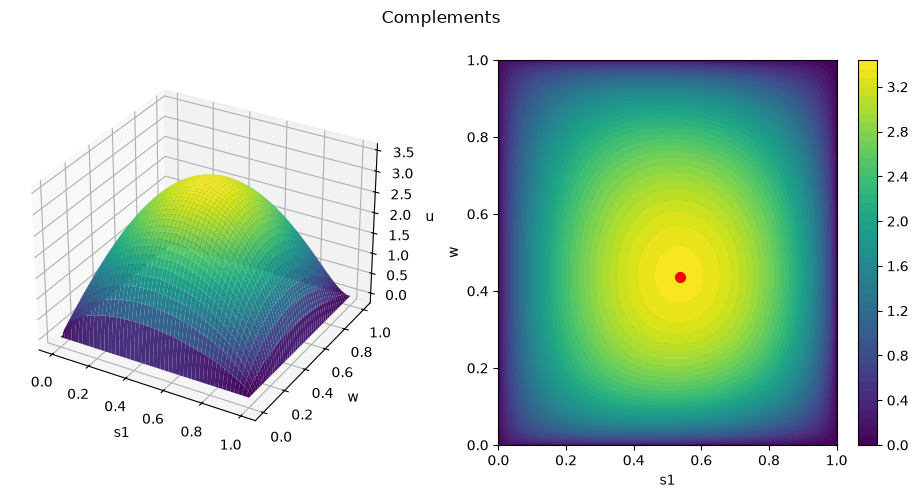

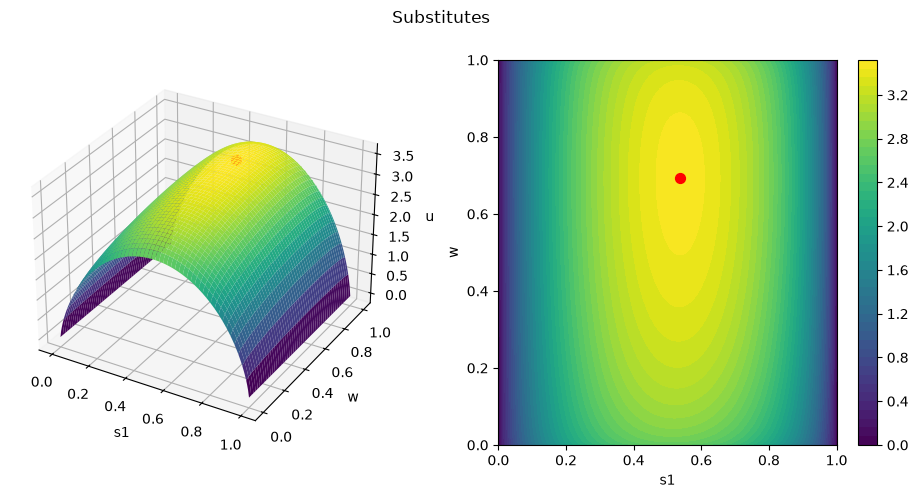

In [153]:
def plot_solution(opt,title):

    fig = plt.figure(figsize=(12,5))
    fig.suptitle(title)

    # a. 3D surface
    ax = fig.add_subplot(1,2,1,projection='3d')
    ax.plot_surface(opt.s1_grid,opt.w_grid,opt.u_grid,cmap='viridis')
    ax.scatter(opt.s1,opt.w,opt.u,color='red',s=50)
    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    ax.set_zlabel('u')

    # b. contour plot
    ax = fig.add_subplot(1,2,2)
    cs = ax.contourf(opt.s1_grid,opt.w_grid,opt.u_grid,levels=50,cmap='viridis')
    ax.scatter(opt.s1,opt.w,color='red',s=50)
    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    fig.colorbar(cs,ax=ax)

    plt.show()

plot_solution(opt_complements,'Complements')
plot_solution(opt_substitutes,'Substitutes')

Comparing the two calibrations: the complements surface has a clearly rounded
peak, so the gradient is informative everywhere near the top. The substitutes
surface instead has a flat ridge running in the $w$-direction near the top -
many combinations of $w$ give almost the same utility once $s_1$ is near its
optimum. This makes the substitutes calibration harder for a gradient-based
optimizer, even though the true optimum is still unique.

Compare N = 50, 100, 500, 1000: How much the solutions moves, and how many evaluations of u it costs.

In [154]:
import time

for model,name in [(model_complements,'Complements'),(model_substitutes,'Substitutes')]:
    print(name)
    for N in [50,100,500,1000]:
        t0 = time.perf_counter()
        opt = model.solve_grid(N=N,do_print=False)
        t1 = time.perf_counter()
        print(f'  N = {N:5d}: s1 = {opt.s1:.4f}, w = {opt.w:.4f}, u = {opt.u:.6f}, ' +
              f'evaluations = {N**2:>8,d}, time = {t1-t0:.4f} s')
    print()

Complements
  N =    50: s1 = 0.5306, w = 0.4490, u = 3.400748, evaluations =    2,500, time = 0.0005 s
  N =   100: s1 = 0.5354, w = 0.4444, u = 3.401482, evaluations =   10,000, time = 0.0007 s
  N =   500: s1 = 0.5351, w = 0.4389, u = 3.401674, evaluations =  250,000, time = 0.0193 s
  N =  1000: s1 = 0.5355, w = 0.4394, u = 3.401680, evaluations = 1,000,000, time = 0.0783 s

Substitutes
  N =    50: s1 = 0.5306, w = 0.6939, u = 3.484594, evaluations =    2,500, time = 0.0010 s
  N =   100: s1 = 0.5354, w = 0.6970, u = 3.485005, evaluations =   10,000, time = 0.0009 s
  N =   500: s1 = 0.5391, w = 0.6914, u = 3.485097, evaluations =  250,000, time = 0.0165 s
  N =  1000: s1 = 0.5385, w = 0.6927, u = 3.485104, evaluations = 1,000,000, time = 0.0710 s



Utility improves smoothly and monotonically for both calibrations as $N$
grows, while the cost rises quadratically with $N$ (from 2,500 to 1,000,000
evaluations). Most of the improvement already happens by $N=100$–$500$;
going to $N=1000$ buys very little extra precision for a 4x increase in cost.

### 2.2

Solve with `solve()`, and compare the solution, the number of function
evaluations, and the running time with the grid search.

In [155]:
for model,name in [(model_complements,'Complements'),(model_substitutes,'Substitutes')]:
    print(name)
    t0 = time.perf_counter()
    opt_lbfgsb = model.solve(do_print=False)
    t1 = time.perf_counter()
    print(f'  L-BFGS-B: s1 = {opt_lbfgsb.s1:.4f}, w = {opt_lbfgsb.w:.4f}, u = {opt_lbfgsb.u:.6f}, ' +
          f'evaluations = {opt_lbfgsb.res.nfev}, time = {t1-t0:.4f} s')
    print()

Complements
  L-BFGS-B: s1 = 0.5356, w = 0.4395, u = 3.401680, evaluations = 18, time = 0.0014 s

Substitutes
  L-BFGS-B: s1 = 0.5382, w = 0.6923, u = 3.485105, evaluations = 27, time = 0.0016 s



L-BFGS-B reaches the same solution as the $N=1000$ grid search (matching to
4+ decimals in $u$) using only 18–27 function evaluations - tens of
thousands of times fewer than the grid, and in a fraction of the time.

Record the convergence path with the callback, and draw it on top of the contour plot. Then plot the distance from each iteration to the final point, on a log scale.

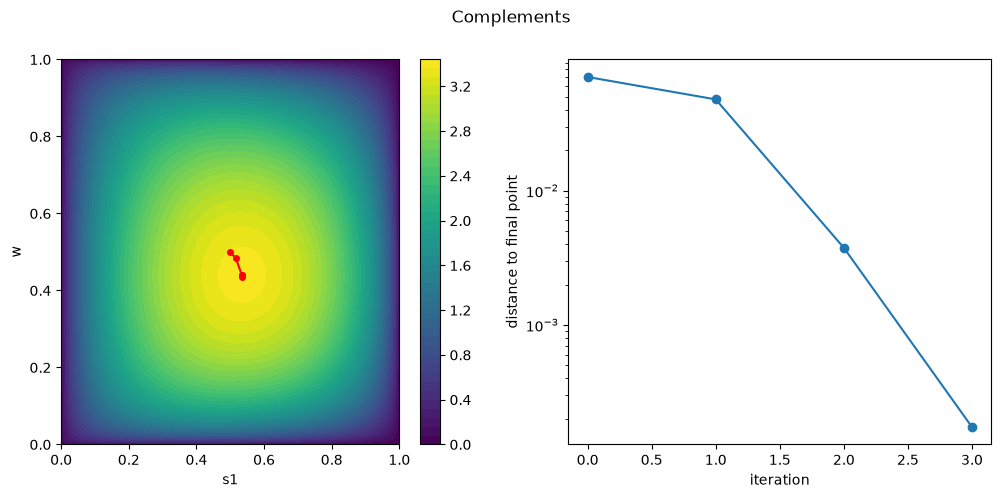

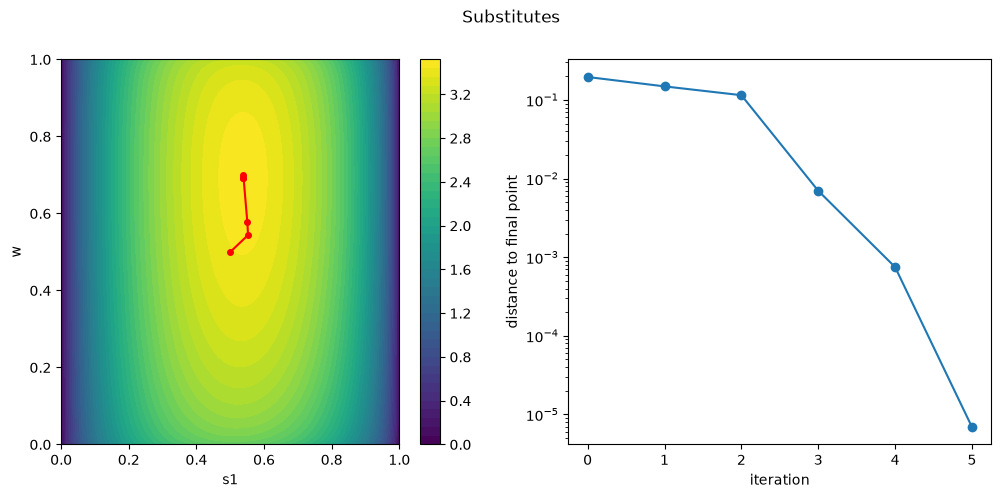

In [156]:
opt_lbfgsb_complements = model_complements.solve(do_print=False)
opt_lbfgsb_substitutes = model_substitutes.solve(do_print=False)

def plot_convergence(opt_grid,opt_lbfgsb,title):

    path = opt_lbfgsb.path

    fig,axes = plt.subplots(1,2,figsize=(12,5))
    fig.suptitle(title)

    # a. contour plot with the path
    ax = axes[0]
    cs = ax.contourf(opt_grid.s1_grid,opt_grid.w_grid,opt_grid.u_grid,levels=50,cmap='viridis')
    ax.plot(path[:,0],path[:,1],'-o',color='red',markersize=4)
    ax.set_xlabel('s1')
    ax.set_ylabel('w')
    fig.colorbar(cs,ax=ax)

    # b. distance to the final point, on a log scale
    ax = axes[1]
    dist = np.linalg.norm(path - path[-1],axis=1)
    ax.plot(dist[:-1],'-o')
    ax.set_yscale('log')
    ax.set_xlabel('iteration')
    ax.set_ylabel('distance to final point')

    plt.show()

plot_convergence(opt_complements,opt_lbfgsb_complements,'Complements')
plot_convergence(opt_substitutes,opt_lbfgsb_substitutes,'Substitutes')

For both calibrations, the path moves almost directly toward the optimum.
The distance to the final point falls close to a straight line on the log
scale, meaning progress is fast in the first couple of iterations and slows
as the solver approaches the peak in the flatter directions.

Solve from at least six different starting points, including the middle (0.5, 0.5) and the four corners of the square. Do you always get the same answer? Does the number of iterations change? One corner fails in one calibration, while still reporting `success = True`.

In [157]:
starting_points = [
    ('middle',[0.5,0.5]),
    ('corner (0,0)',[0.0,0.0]),
    ('corner (0,1)',[0.0,1.0]),
    ('corner (1,0)',[1.0,0.0]),
    ('corner (1,1)',[1.0,1.0]),
    ('near (0,0)',[0.01,0.01]),
]

for model,name in [(model_complements,'Complements'),(model_substitutes,'Substitutes')]:
    print(name)
    for label,s0 in starting_points:
        opt = model.solve(s0=s0,do_print=False)
        print(f'  {label:15s}: s1 = {opt.s1:.4f}, w = {opt.w:.4f}, u = {opt.u:.6f}, ' +
              f'nit = {opt.res.nit}, success = {opt.res.success}')
    print()

Complements
  middle         : s1 = 0.5356, w = 0.4395, u = 3.401680, nit = 4, success = True
  corner (0,0)   : s1 = 0.5356, w = 0.4395, u = 3.401680, nit = 7, success = True
  corner (0,1)   : s1 = 0.5356, w = 0.4395, u = 3.401680, nit = 9, success = True
  corner (1,0)   : s1 = 1.0000, w = 0.0000, u = 0.000000, nit = 1, success = True
  corner (1,1)   : s1 = 1.0000, w = 1.0000, u = 0.000000, nit = 1, success = True
  near (0,0)     : s1 = 0.5356, w = 0.4395, u = 3.401680, nit = 6, success = True

Substitutes
  middle         : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 6, success = True
  corner (0,0)   : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 18, success = True
  corner (0,1)   : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 17, success = True
  corner (1,0)   : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 18, success = True
  corner (1,1)   : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 16, success = True
  near (0,0)     : s1 = 0.5382, w = 0.6923, u = 3.485105, nit = 8, su

L-BFGS-B always finds the same answer in the substitutes calibration,
regardless of starting point. In complements, however, the corners
$(1,0)$ and $(1,1)$ fail: the solver stops after `nit = 1` with $u = 0$,
while still reporting `success = True`. Both starting points have $s_1=1$,
which floors $x_2$ and $x_3$ to `par.s_min`. Because $\sigma_B<1$ here, the
lower nest is dominated by whichever quantity is smallest, so a small step
away from the floor barely changes utility - the estimated gradient is
numerically zero, and L-BFGS-B incorrectly reports convergence at the very
first point. This does not happen for substitutes, since $\sigma_B>1$ makes
the nest behave more like an average, so the gradient is picked up correctly
even at the boundary.

Vary `ftol`and `gtol`, and report the two shares, the utility reached, and the number of function evaluations for each setting in one table.

In [158]:
settings = [('ftol',1e-4),('ftol',1e-8),('ftol',1e-12),('ftol',1e-16),
            ('gtol',1e-2),('gtol',1e-5),('gtol',1e-8),('gtol',1e-12)]

rows = []
for name,model in [('Complements',model_complements),('Substitutes',model_substitutes)]:
    for setting,value in settings:
        opt = model.solve(do_print=False,options={setting:value})
        rows.append({'calibration':name,'setting':setting,'value':value,
                     's1':opt.s1,'w':opt.w,'u':opt.u,'nfev':opt.res.nfev})

df = pd.DataFrame(rows)
df

,calibration,setting,value,s1,w,u,nfev
0,Complements,ftol,1.000000e-04,0.535607,0.439652,3.401680,15
1,Complements,ftol,1.000000e-08,0.535623,0.439479,3.401680,18
2,Complements,ftol,1.000000e-12,0.535623,0.439479,3.401680,18
3,Complements,ftol,1.000000e-16,0.535623,0.439479,3.401680,18
4,Complements,gtol,1.000000e-02,0.535607,0.439652,3.401680,15
5,Complements,gtol,1.000000e-05,0.535623,0.439479,3.401680,18
6,Complements,gtol,1.000000e-08,0.535624,0.439478,3.401680,21
7,Complements,gtol,1.000000e-12,0.535624,0.439478,3.401680,21
8,Substitutes,ftol,1.000000e-04,0.538155,0.691562,3.485104,21
9,Substitutes,ftol,1.000000e-08,0.538225,0.692308,3.485105,27


From `ftol=1e-8` (or `gtol=1e-5`) onward, $s_1$, $w$ and $u$ no longer change
for either calibration - only the evaluation count creeps up slightly. We
would use `ftol=1e-8` and `gtol=1e-5`: tighter tolerances cost extra
evaluations without changing the answer, because the improvement they chase
is smaller than the numerical precision the model can actually distinguish
(cf. floating-point precision) - a tighter tolerance is not always better.

### 1.3

Two cheap checks, using the results from section 2: (1) is the answer possible - shares strictly between 0 and 1, summing to one, quantities positive; (2) do the two solution methods (grid search and L-BFGS-B) agree?

In [159]:
for name,opt_grid,opt_lbfgsb,model in [
    ('Complements',opt_complements,opt_lbfgsb_complements,model_complements),
    ('Substitutes',opt_substitutes,opt_lbfgsb_substitutes,model_substitutes)]:

    print(name)

    # a. is the answer possible?
    x1,x2,x3 = model.quantities(opt_lbfgsb.s1,opt_lbfgsb.w)
    shares_ok = all(0 < s < 1 for s in (opt_lbfgsb.s1,opt_lbfgsb.s2,opt_lbfgsb.s3))
    sum_ok = np.isclose(opt_lbfgsb.s1+opt_lbfgsb.s2+opt_lbfgsb.s3,1.0)
    quantities_ok = all(x > 0 for x in (x1,x2,x3))
    print(f'  possible: shares in (0,1) = {shares_ok}, sum to 1 = {sum_ok}, quantities > 0 = {quantities_ok}')

    # b. do grid search and L-BFGS-B agree?
    agree = np.isclose(opt_grid.u,opt_lbfgsb.u,atol=1e-3)
    print(f'  agreement: grid u = {opt_grid.u:.6f}, L-BFGS-B u = {opt_lbfgsb.u:.6f}, agree = {agree}')
    print()

Complements
  possible: shares in (0,1) = True, sum to 1 = True, quantities > 0 = True
  agreement: grid u = 3.401601, L-BFGS-B u = 3.401680, agree = True

Substitutes
  possible: shares in (0,1) = True, sum to 1 = True, quantities > 0 = True
  agreement: grid u = 3.485100, L-BFGS-B u = 3.485105, agree = True



Both cheap checks pass for both calibrations: all three shares lie strictly
between 0 and 1 and sum to one, all three quantities are positive, and the
two independent solution methods (grid search and L-BFGS-B) agree on the
utility reached. This gives confidence that sections 1–2 are solved
correctly.